# A6 Generative Adversarial Networks

- ***Name:*** Zoe McFife
- ***Legal Name and Student NR:*** Bunea, S2510238021
- ***Time Spent:*** 03:00:00

# Generative Adversarial Networks - Fruits

Based on [https://www.tensorflow.org/tutorials/generative/dcgan](https://www.tensorflow.org/tutorials/generative/dcgan); modified from MNIST to Fruits-360 data.

## Setup


In [9]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [10]:
## adapt this directory to your needs
## adapt this directory to your needs
base_dir = '/content/drive/MyDrive/'
notebook_dir = base_dir + 'Colab\ Notebooks/'
data_dir = base_dir + 'Colab\ Notebooks/Datasets'

<>:4: SyntaxWarning: invalid escape sequence '\ '
<>:5: SyntaxWarning: invalid escape sequence '\ '
<>:4: SyntaxWarning: invalid escape sequence '\ '
<>:5: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_5127/2413031977.py:4: SyntaxWarning: invalid escape sequence '\ '
  notebook_dir = base_dir + 'Colab\ Notebooks/'
/tmp/ipykernel_5127/2413031977.py:5: SyntaxWarning: invalid escape sequence '\ '
  data_dir = base_dir + 'Colab\ Notebooks/Datasets'


In [2]:
## if using Colab, you need to run this every time you start a notebook
## on a local installation, you only need to run this once (or install the
## pyMLaux package outside of the notebook once and for all)
!pip install git+https://github.com/UBod/pyMLaux.git

  Cloning https://github.com/UBod/pyMLaux.git to /tmp/pip-req-build-krj0kgst
  Running command git clone --filter=blob:none --quiet https://github.com/UBod/pyMLaux.git /tmp/pip-req-build-krj0kgst
  Resolved https://github.com/UBod/pyMLaux.git to commit bf7c7e39ae37cb55c6fd06dca3ae7d53f4a82086
  Preparing metadata (setup.py) ... done
  Created wheel for pyMLaux: filename=pyMLaux-0.0.12-py3-none-any.whl size=7343 sha256=31446d7408e9fc39f979be2efa5087da044b0caf1c3d087a1f70e910f42b6960
  Stored in directory: /tmp/pip-ephem-wheel-cache-ah39jqs7/wheels/11/ac/3e/948e9f1512cca2f8abeec2c01c553c26aa19a304dfff815e28
Successfully built pyMLaux


In [3]:
import os

import numpy as np
import tensorflow as tf

from pyMLaux import show_img_data

In [4]:
tf.get_logger().setLevel('ERROR')

device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
    raise SystemError('GPU device not found')
print('Found GPU at: {}'.format(device_name))

Found GPU at: /device:GPU:0


In [11]:
## unzip data to local directory on Colab runtime
## (must be redone every time, since Colab kills the runtime's local memory each time )
%%capture
!cd ~; unzip -n $data_dir/fruits_a.zip
!cd ~; unzip -n $data_dir/fruits_b.zip

In [12]:
data_dir = os.path.expanduser('~/fruits-360/Training/')
batch_size = 128
img_height, img_width = 32, 32

train_img = tf.keras.preprocessing.image_dataset_from_directory(data_dir,
                                                                image_size=(img_height, img_width),
                                                                batch_size=batch_size)

Found 67692 files belonging to 131 classes.


In [13]:
## put everything into a numpy array
train_x_list = [img_batch.numpy() / 255. for img_batch, label_batch in train_img]
train_x = np.concatenate(train_x_list)

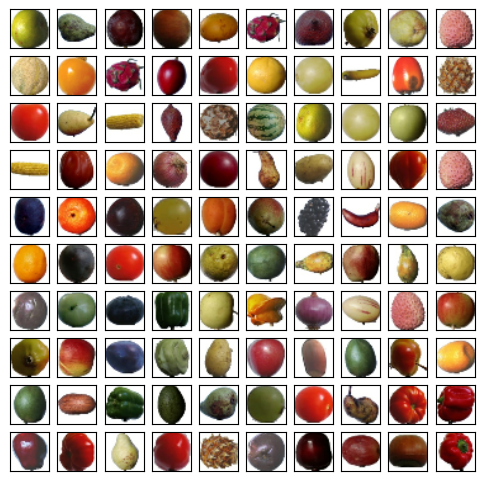

In [14]:
show_img_data(train_x, no=100, layout=(10, 10), figsize=(6, 6))

In [15]:
buffer_size = 60000
train_dataset = tf.data.Dataset.from_tensor_slices(train_x.reshape(train_x.shape[0], train_x.shape[1], train_x.shape[2], 3)).shuffle(buffer_size).batch(batch_size)

## Set Up Generator and Discriminator Models

In [16]:
latent_dim = 150

def make_generator_model():
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Dense(4 * 4 * 256, use_bias=False, input_shape=(latent_dim,)))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.LeakyReLU(alpha=0.2))

    model.add(tf.keras.layers.Reshape((4, 4, 256)))
    assert model.output_shape == (None, 4, 4, 256)

    model.add(tf.keras.layers.Conv2DTranspose(128, (4, 4), strides=(2, 2), padding='same', use_bias=False))
    assert model.output_shape == (None, 8, 8, 128)
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.LeakyReLU(alpha=0.2))

    model.add(tf.keras.layers.Conv2DTranspose(128, (4, 4), strides=(2, 2), padding='same', use_bias=False))
    assert model.output_shape == (None, 16, 16, 128)
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.LeakyReLU(alpha=0.2))

    model.add(tf.keras.layers.Conv2DTranspose(128, (4, 4), strides=(2, 2), padding='same', use_bias=False))
    assert model.output_shape == (None, 32, 32, 128)
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.LeakyReLU())

    model.add(tf.keras.layers.Conv2D(3, (3, 3), strides=(1, 1), padding='same', use_bias=False, activation='sigmoid'))
    assert model.output_shape == (None, 32, 32, 3)

    return model

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


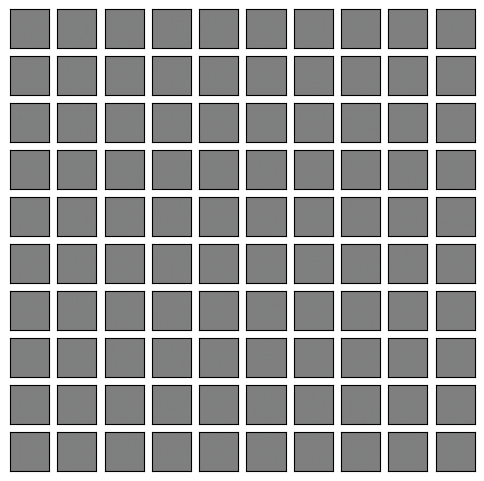

In [17]:
generator = make_generator_model()

noise = tf.random.normal([100, latent_dim])
generated_image = generator(noise, training=False)

show_img_data(generated_image, no=100, layout=(10, 10), figsize=(6, 6))

In [18]:
generator.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4096)           │       614,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 4096)           │        16,384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 128)      │       524,288 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 128)    │       262,144 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 128)    │       262,144 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 3)      │         3,456 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,684,352 (6.43 MB)

 Trainable params: 1,675,392 (6.39 MB)

 Non-trainable params: 8,960 (35.00 KB)

In [19]:
def generate_and_show_images(model, test_input):
    # Notice `training` is set to False in order to make sure that
    # all layers run in inference mode (batchnorm).
    predictions = model(test_input, training=False)

    show_img_data(predictions, no=min(100, test_input.shape[0]), layout=(10, 10), figsize=(6, 6))

In [20]:
def make_discriminator_model():
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Conv2D(64, (3, 3), strides=(1, 1), padding='same',
                                     input_shape=[32, 32, 3]))
    model.add(tf.keras.layers.LeakyReLU(alpha=0.2))

    model.add(tf.keras.layers.Conv2D(128, (3, 3), strides=(1, 1), padding='same'))
    model.add(tf.keras.layers.LeakyReLU(alpha=0.2))

    model.add(tf.keras.layers.Conv2D(128, (3, 3), strides=(1, 1), padding='same'))
    model.add(tf.keras.layers.LeakyReLU(alpha=0.2))

    model.add(tf.keras.layers.Conv2D(256, (3, 3), strides=(1, 1), padding='same'))
    model.add(tf.keras.layers.LeakyReLU(alpha=0.2))

    model.add(tf.keras.layers.Flatten())
    model.add(tf.keras.layers.Dropout(0.4))
    model.add(tf.keras.layers.Dense(1))

    return model

In [21]:
discriminator = make_discriminator_model()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Define Losses and Optimizers

In [22]:
## This method returns a helper function to compute cross entropy loss
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

In [23]:
def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    total_loss = real_loss + fake_loss
    return total_loss

In [24]:
def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

In [25]:
generator_optimizer = tf.keras.optimizers.Adam(1.6e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(2e-4)

In [27]:
checkpoint_dir = '/content/drive/MyDrive/Colab Notebooks/models/Fruits/training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer,
                                 discriminator_optimizer=discriminator_optimizer,
                                 generator=generator,
                                 discriminator=discriminator)

## Define the Training Loop

In [28]:
no_epochs = 60
num_examples = 100

# We will reuse this seed over time
gan_seed = tf.random.normal([num_examples, latent_dim])

In [29]:
# Notice the use of `tf.function`
# This annotation causes the function to be "compiled".
@tf.function
def train_step(images):
    noise = tf.random.normal([batch_size, latent_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

In [32]:
def train(dataset, epochs):
    for epoch in range(epochs):
        for image_batch in dataset:
            train_step(image_batch)

        # show images
        print('Epoch ' + str(epoch + 1) + ' ... finished')

        # save the model every 5 epochs
        if (epoch + 1) % 2 == 0:
            generate_and_show_images(generator, gan_seed)
            checkpoint.save(file_prefix=checkpoint_prefix)

## Run Training

In [33]:
train(train_dataset, no_epochs)

Output hidden; open in https://colab.research.google.com to view.

## Play Around with Trained Model

In [34]:
## load latest model
latest = tf.train.latest_checkpoint(checkpoint_dir)
status = checkpoint.restore(tf.train.latest_checkpoint(checkpoint_dir))

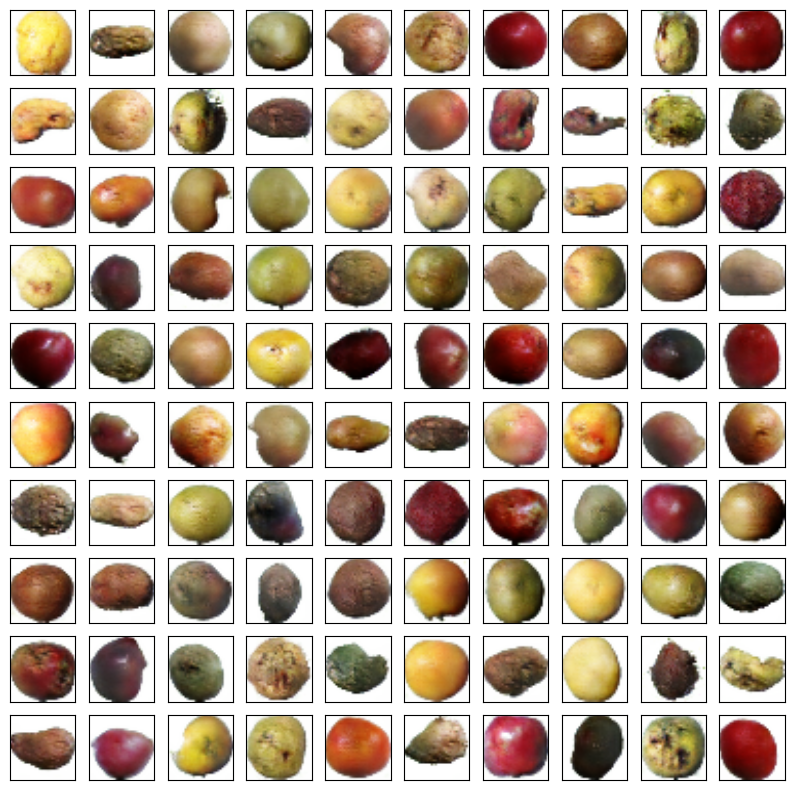

In [38]:
## generate 100 images
noise = np.random.normal(size=[100, latent_dim])
generated_image = generator(noise, training=False)

show_img_data(generated_image, no=100, layout=(10, 10))

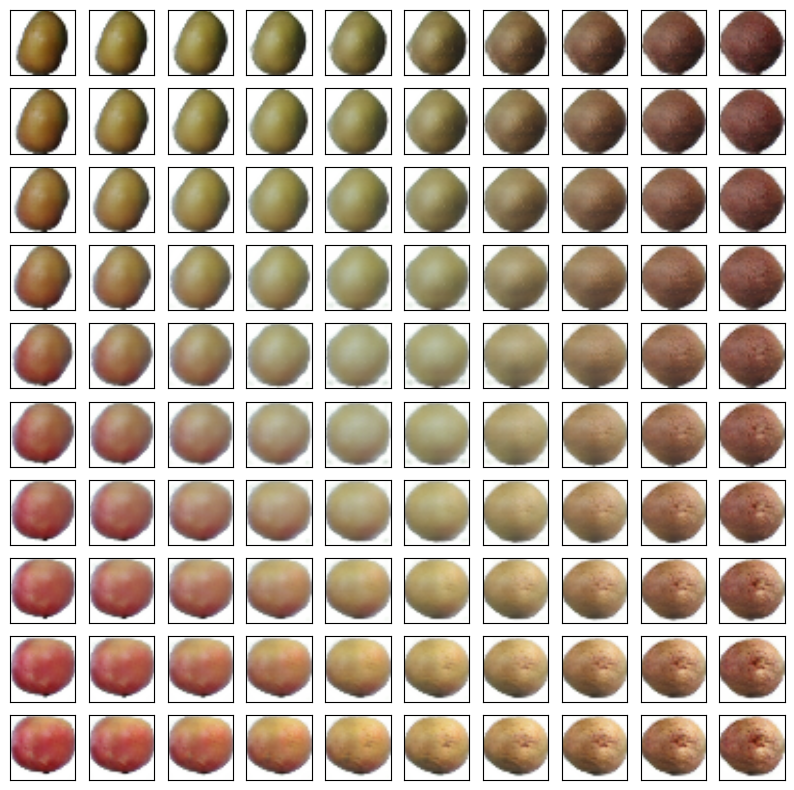

In [37]:
n, m = 10, 10

noise = np.random.normal(size=[n * m, latent_dim], scale=0.01)
noise[:, (98, 99)] = np.array(np.meshgrid(np.linspace(-6, 6, num=n), np.linspace(-6, 6, num=m))).T.reshape(n * m, 2)
generated_image = generator(noise, training=False)

show_img_data(generated_image, no=(n * m), layout=(n, m))

In [ ]:
!cd $notebook_dir; jupyter nbconvert --to html GAN_Fruits.ipynb

[NbConvertApp] Converting notebook GAN_Fruits.ipynb to html
